# Fake Speech Data Plots\n
\n
This notebook builds the visualizations from real recordings in `Sound_recordings/` and matching analysis outputs.

In [1]:
# Optional: install dependencies if missing (run once).
# Uncomment if needed:
# %pip install numpy matplotlib pandas ipywidgets librosa plotly

import json
import re
from datetime import datetime
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, to_rgb

In [2]:


PALETTE_HEX = ['#FF7979', '#21AFA2', '#1E8486', '#666563', '#327D79', '#27636D']
PRIMARY_TEAL = '#21AFA2'
DEEP_TEAL = '#1E8486'
SLATE = '#666563'
DARK_TEAL = '#27636D'
ACCENT_CORAL = '#FF7979'

HEATMAP_CMAP = LinearSegmentedColormap.from_list(
    'filler_teal_gradient',
    ['#F2FBFA', '#CFEDEA', '#8FD7D0', PRIMARY_TEAL, DEEP_TEAL, DARK_TEAL],
)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 12,
    'axes.titlesize': 18,
    'axes.labelsize': 14,
    'axes.titleweight': 'bold',
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'legend.title_fontsize': 13,
    'figure.titlesize': 19,
    'axes.prop_cycle': plt.cycler(color=PALETTE_HEX),
})

In [8]:
SOUND_ANALYSIS_DIR = Path('sound_analysis')

if not SOUND_ANALYSIS_DIR.exists():
    raise FileNotFoundError(f'Could not find folder: {SOUND_ANALYSIS_DIR}')

analysis_files = sorted(SOUND_ANALYSIS_DIR.glob('*.json'))
if not analysis_files:
    raise FileNotFoundError(f'No .json files found in: {SOUND_ANALYSIS_DIR}')

def parse_timestamp(name):
    match = re.search(r'(\d{8}_\d{6})', name)
    return match.group(1) if match else None

def parse_timestamp_datetime(name):
    ts = parse_timestamp(name)
    if not ts:
        return None
    try:
        return datetime.strptime(ts, '%Y%m%d_%H%M%S')
    except ValueError:
        return None

def parse_created_at_datetime(item, fallback_name=''):
    created_at = str(item.get('created_at', '')).strip()
    if created_at:
        try:
            return datetime.fromisoformat(created_at)
        except ValueError:
            pass
    return parse_timestamp_datetime(fallback_name)

def load_json_if_exists(path):
    if path.exists():
        try:
            return json.loads(path.read_text(encoding='utf-8-sig'))
        except (json.JSONDecodeError, UnicodeDecodeError):
            try:
                return json.loads(path.read_text(encoding='utf-8'))
            except (json.JSONDecodeError, UnicodeDecodeError):
                return {}
    return {}

def build_filler_events_from_counts(filler_counts, duration):
    words_expanded = []
    for word, count in sorted(filler_counts.items()):
        safe_count = max(0, int(count))
        words_expanded.extend([word] * safe_count)

    total = len(words_expanded)
    if total == 0:
        return []

    end_time = max(float(duration), 1.0)
    events = []
    for idx, word in enumerate(words_expanded):
        ratio = float((idx + 0.5) / total)
        t = float(ratio * end_time)
        events.append({
            'word': word,
            'position_ratio': ratio,
            'time': t,
        })

    return events

def build_filler_time_bins(events, filler_words, duration, bin_size=10.0):
    end_time = max(float(duration), bin_size)
    edges = np.arange(0.0, end_time + bin_size, bin_size)
    bins = []

    for start, end in zip(edges[:-1], edges[1:]):
        item = {'time_start': float(start), 'time_end': float(end), **{w: 0 for w in filler_words}}
        for event in events:
            t = event['time']
            if (start <= t < end) or (t == end_time and end == end_time):
                item[event['word']] = item.get(event['word'], 0) + 1
        item['total'] = int(sum(item[w] for w in filler_words))
        bins.append(item)

    return bins

def build_rolling_wpm(total_words, duration):
    if duration <= 0:
        return [{'time': 1.0, 'wpm': 0.0}]
    times = np.arange(1.0, max(2.0, np.floor(duration) + 1), 1.0)
    if total_words > 0:
        word_times = np.linspace(0.0, duration, total_words, endpoint=False)
    else:
        word_times = np.array([])

    series = []
    for t in times:
        start = max(0.0, t - 30.0)
        count = int(np.sum((word_times > start) & (word_times <= t)))
        series.append({'time': float(t), 'wpm': float(count * 2.0)})
    return series

recordings = []
filler_words_set = set()

for analysis_path in analysis_files:
    item = load_json_if_exists(analysis_path)
    if not item:
        continue

    recording_id = analysis_path.stem
    speed = item.get('speed', {}) if isinstance(item.get('speed'), dict) else {}
    filler = item.get('filler', {}) if isinstance(item.get('filler'), dict) else {}
    pitch = item.get('pitch', {}) if isinstance(item.get('pitch'), dict) else {}
    pitch_summary = pitch.get('summary', {}) if isinstance(pitch.get('summary'), dict) else {}
    pitch_series = pitch.get('series', []) if isinstance(pitch.get('series'), list) else []

    duration_seconds = float(speed.get('duration_seconds', 0.0) or 0.0)
    total_words_rec = int(speed.get('total_words', filler.get('total_words', 0)) or 0)
    wpm = float(speed.get('wpm', 0.0) or 0.0)

    filler_counts_raw = filler.get('filler_word_counts', {}) if isinstance(filler, dict) else {}
    filler_counts = {
        str(word): int(count)
        for word, count in filler_counts_raw.items()
        if isinstance(word, str) and int(count) > 0
    }
    filler_words_set.update(filler_counts.keys())

    total_filler_words = int(filler.get('total_filler_words', sum(filler_counts.values())) or 0)
    filler_percentage = float(filler.get('filler_percentage', 0.0) or 0.0)

    events = build_filler_events_from_counts(filler_counts, duration_seconds)
    rolling_wpm = build_rolling_wpm(total_words_rec, duration_seconds)

    pitch_track = [
        {
            'time': float(point.get('time', 0.0) or 0.0),
            'pitch_hz': None if point.get('pitch_hz') is None else float(point.get('pitch_hz')),
            'pitch_st': None if point.get('pitch_semitones') is None else float(point.get('pitch_semitones')),
            'voiced': bool(point.get('voiced', False)),
        }
        for point in pitch_series
        if isinstance(point, dict)
    ]

    recordings.append({
        'recording_id': recording_id,
        'recording_dt': parse_created_at_datetime(item, fallback_name=recording_id),
        'filler_events': events,
        'rolling_wpm_30s': rolling_wpm,
        'pitch_track': pitch_track,
        'pitch_summary': {
            'median_hz': float(pitch_summary.get('median_pitch', 0.0) or 0.0),
            'min_hz': float(pitch_summary.get('min_pitch', 0.0) or 0.0),
            'max_hz': float(pitch_summary.get('max_pitch', 0.0) or 0.0),
            'mean_st': float(pitch_summary.get('mean_pitch_semitones', 0.0) or 0.0),
            'min_st': float(pitch_summary.get('min_pitch_semitones', 0.0) or 0.0),
            'max_st': float(pitch_summary.get('max_pitch_semitones', 0.0) or 0.0),
            'median_st': float(pitch_summary.get('median_pitch_semitones', 0.0) or 0.0),
            'reference_hz': float(pitch_summary.get('pitch_reference_hz', 0.0) or 0.0),
            'voiced_ratio': float(pitch_summary.get('voiced_ratio', 0.0) or 0.0),
        },
        'duration_seconds': duration_seconds,
        'total_words': total_words_rec,
        'wpm': wpm,
        'total_filler_words': total_filler_words,
        'filler_percentage': filler_percentage,
        'filler_word_counts': filler_counts,
    })

recordings = sorted(
    recordings,
    key=lambda r: (r.get('recording_dt') or datetime.max, r.get('recording_id', ''))
 )

# Use observed filler words from sound_analysis; fallback keeps plots stable if all counts are 0
filler_words = sorted(filler_words_set) if filler_words_set else ['uh', 'um', 'like', 'you know']

for rec in recordings:
    rec['filler_time_bins'] = build_filler_time_bins(
        rec.get('filler_events', []),
        filler_words,
        rec.get('duration_seconds', 0.0),
    )

recording_ids = [r['recording_id'] for r in recordings]

all_filler_counts = Counter()
for rec in recordings:
    all_filler_counts.update(rec.get('filler_word_counts', {}))

# Ensure every filler axis label appears in summary, even if count is 0
for filler_word in filler_words:
    all_filler_counts.setdefault(filler_word, 0)

total_words_all = int(sum(rec.get('total_words', 0) for rec in recordings))
total_fillers_all = int(sum(all_filler_counts.values()))
overall_pct = round((100.0 * total_fillers_all / total_words_all), 3) if total_words_all else 0.0

data = {
    'recordings': recordings,
    'total_words': total_words_all,
    'total_filler_words': total_fillers_all,
    'overall_filler_percentage': overall_pct,
    'filler_word_summary': [
        {'word': w, 'count': int(all_filler_counts.get(w, 0))}
        for w in filler_words
    ],
}

print(f"Loaded {len(recordings)} recordings")
print('Data source: sound_analysis')
print(f"Filler vocabulary: {filler_words}")
print(f"Total words: {data['total_words']}")
print(f"Total fillers: {data['total_filler_words']} ({data['overall_filler_percentage']}%)")

Loaded 41 recordings
Data source: sound_analysis
Filler vocabulary: ['actually', 'blah', 'i guess', 'i mean', 'kind of', 'like', 'okay', 'right', 'so', 'well', 'yeah', 'you know']
Total words: 1165
Total fillers: 68 (5.837%)


## 1) Filler counts by recording

This replaces the synthetic position-density view with a clearer count-based chart that shows how many fillers appear in each recording, broken down by filler word.

In [4]:
import plotly.graph_objects as go
import ipywidgets as widgets
import colorsys
from IPython.display import display


def _clean_recording_label(recording_id):
    return re.sub(r'_\d{8}_\d{6}$', '', recording_id)


def _build_unique_word_colors(words):
    total = max(1, len(words))
    colors = {}
    for i, word in enumerate(words):
        hue = float(i) / float(total)
        r, g, b = colorsys.hls_to_rgb(hue, 0.50, 0.72)
        colors[word] = '#{:02x}{:02x}{:02x}'.format(int(r * 255), int(g * 255), int(b * 255))
    return colors


if not recordings:
    print('No recordings available.')
else:
    word_colors = _build_unique_word_colors(filler_words)

    n_options = [5, 10, 15, 20]
    default_n = 10 if len(recordings) >= 1 else 5

    recording_window_dropdown = widgets.Dropdown(
        options=[(f'Last {n} recordings', n) for n in n_options],
        value=default_n,
        description='Show:',
        layout=widgets.Layout(width='280px'),
    )

    legend_items_html = ''.join(
        f"<div style='display:flex; align-items:center; margin:4px 0;'>"
        f"<span style='display:inline-block; width:12px; height:12px; margin-right:8px; border:1px solid #64748b; background:{word_colors[word]};'></span>"
        f"<span style='font-size:13px; color:#1f2937;'>{word}</span>"
        f"</div>"
        for word in filler_words
    )
    legend_panel = widgets.HTML(
        value=(
            "<div style='padding:10px 12px; border:1px solid #d1d5db; border-radius:6px;"
            " background:#ffffff; min-width:180px;'>"
            "<div style='font-weight:700; margin-bottom:8px; color:#1f2937;'>Filler word</div>"
            f"{legend_items_html}"
            "</div>"
        )
    )
    legend_panel.layout = widgets.Layout(width='220px', margin='0 0 0 10px')

    def _build_filler_counts_plot(last_n):
        selected_recordings = recordings[-last_n:]
        ordered_recordings = sorted(
            selected_recordings,
            key=lambda rec: int(sum(rec.get('filler_word_counts', {}).values())),
            reverse=True,
        )

        ordered_ids = [rec.get('recording_id', 'unknown') for rec in ordered_recordings]
        display_labels = [_clean_recording_label(rid) for rid in ordered_ids]
        ordered_totals = [int(sum(rec.get('filler_word_counts', {}).values())) for rec in ordered_recordings]

        fig = go.Figure()
        for word in filler_words:
            values = [int(rec.get('filler_word_counts', {}).get(word, 0)) for rec in ordered_recordings]
            fig.add_trace(
                go.Bar(
                    x=values,
                    y=ordered_ids,
                    orientation='h',
                    name=word,
                    showlegend=False,
                    marker={
                        'color': word_colors[word],
                        'line': {'color': 'white', 'width': 1},
                    },
                    hovertemplate='<b>Filler word:</b> %{fullData.name}<br><b>Count:</b> %{x}<extra></extra>',
                )
            )

        fig.add_trace(
            go.Scatter(
                x=ordered_totals,
                y=ordered_ids,
                mode='text',
                text=[str(total) for total in ordered_totals],
                textposition='middle right',
                textfont={'size': 13, 'color': '#1f2937'},
                showlegend=False,
                hoverinfo='skip',
            )
        )

        max_total = max(ordered_totals) if ordered_totals else 0

        fig.update_layout(
            title=f'Filler Counts by Recording (Last {last_n}, Ordered by Total)',
            barmode='stack',
            xaxis_title='Filler count',
            yaxis_title='Recording',
            template='plotly_white',
            width=600,
            height=max(450, 120 + 36 * len(ordered_recordings)),
            margin={'l': 180, 'r': 35, 't': 80, 'b': 70},
            showlegend=False,
            font={'family': 'DejaVu Sans', 'size': 13, 'color': '#1f2937'},
            hoverlabel={
                'align': 'left',
                'namelength': -1,
                'font': {'size': 14},
                'bgcolor': 'rgba(245, 252, 251, 0.98)',
                'bordercolor': DEEP_TEAL,
            },
        )
        fig.update_xaxes(
            range=[0, max_total * 1.16 + 1],
            showgrid=True,
            gridcolor='rgba(39, 99, 109, 0.14)',
        )
        fig.update_yaxes(
            categoryorder='array',
            categoryarray=ordered_ids[::-1],
            tickmode='array',
            tickvals=ordered_ids,
            ticktext=display_labels,
            showgrid=False,
        )
        fig.show()

    out = widgets.interactive_output(_build_filler_counts_plot, {'last_n': recording_window_dropdown})
    out.layout = widgets.Layout(width='600px')
    display(widgets.VBox([recording_window_dropdown, widgets.HBox([out, legend_panel], layout=widgets.Layout(align_items='flex-start'))]))

## 3) Pace over time (rolling 30-second WPM)

Rolling 30-second WPM means the speaking rate is calculated using a moving 30-second window across the recording. At each time point, words spoken in the most recent 30 seconds are converted to words per minute, which helps smooth short-term noise while still showing pace changes over time.

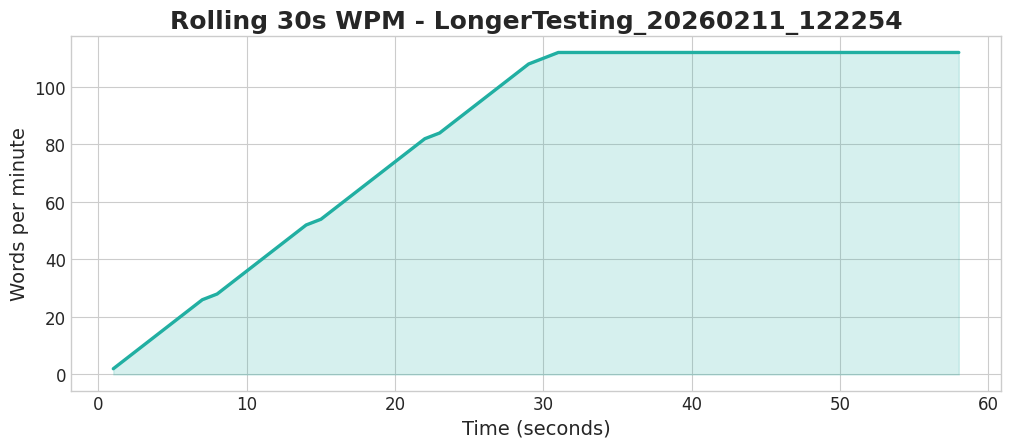

In [10]:
selected_id = next(
    (
        rec['recording_id']
        for rec in recordings
        if any(float(point.get('wpm', 0.0) or 0.0) > 0 for point in rec.get('rolling_wpm_30s', []))
    ),
    recording_ids[0],
)
rec = next(r for r in recordings if r['recording_id'] == selected_id)
rw = rec['rolling_wpm_30s']
times = [p['time'] for p in rw]
wpm = [p['wpm'] for p in rw]

plt.figure(figsize=(12, 4.6))
plt.plot(times, wpm, color=PRIMARY_TEAL, linewidth=2.4)
plt.fill_between(times, wpm, alpha=0.18, color=PRIMARY_TEAL)
plt.title(f"Rolling 30s WPM - {selected_id}")
plt.xlabel('Time (seconds)')
plt.ylabel('Words per minute')
plt.show()

## 4) Heatmap of filler words by month (percentage per word)

This view shows each filler word's share of all spoken words in a month.

- X-axis: month
- Y-axis: filler word
- Cell value: occurrences of that filler word divided by total words spoken in that month, shown as a percentage
- Hover: percentage, raw filler count, and total words in that month

In [6]:
from collections import defaultdict
from datetime import datetime

year_options = sorted({
    dt.year
    for rec in recordings
    if (dt := parse_timestamp_datetime(rec.get('recording_id', ''))) is not None
})

months_by_year = {year: [f'{year}-{month:02d}' for month in range(1, 13)] for year in year_options}

if not year_options:
    print('No timestamped recordings found for month-based heatmap.')
else:
    selected_year = year_options[-1]
    month_labels = months_by_year[selected_year]

    month_total_words_by_year = defaultdict(lambda: defaultdict(int))
    month_recording_counts_by_year = defaultdict(lambda: defaultdict(int))
    month_word_counts_by_year = {word: defaultdict(lambda: defaultdict(int)) for word in filler_words}

    for rec in recordings:
        rec_id = rec.get('recording_id', '')
        rec_dt = parse_timestamp_datetime(rec_id)
        if rec_dt is None:
            continue

        year_key = rec_dt.year
        month_key = f'{year_key}-{rec_dt.month:02d}'
        total_words_rec = max(0, int(rec.get('total_words', 0)))
        month_total_words_by_year[year_key][month_key] += total_words_rec
        month_recording_counts_by_year[year_key][month_key] += 1

        rec_counts = rec.get('filler_word_counts', {})
        for word in filler_words:
            month_word_counts_by_year[word][year_key][month_key] += int(rec_counts.get(word, 0))

In [7]:
import plotly.graph_objects as go
import numpy as np
import ipywidgets as widgets
from IPython.display import display
from datetime import datetime

if not year_options:
    print('No month data available for the heatmap.')
else:
    year_dropdown_heatmap = widgets.Dropdown(
        options=[(str(year), year) for year in year_options],
        value=year_options[-1],
        description='Year:',
        layout=widgets.Layout(width='220px'),
    )

    def _build_month_heatmap(selected_year):
        month_labels = months_by_year[selected_year]
        year_month_totals = month_total_words_by_year.get(selected_year, {})
        year_month_recordings = month_recording_counts_by_year.get(selected_year, {})

        def _sum_month_rate(word):
            total_rate = 0.0
            for month in month_labels:
                month_total_words = year_month_totals.get(month, 0)
                raw_count = int(month_word_counts_by_year[word][selected_year].get(month, 0))
                total_rate += (100.0 * raw_count / month_total_words) if month_total_words else 0.0
            return total_rate

        filler_order = sorted(filler_words, key=_sum_month_rate, reverse=True)

        z_percentages = []
        raw_counts = []
        month_words_matrix = []
        month_recording_matrix = []
        for word in filler_order:
            row_percentage = []
            row_raw = []
            row_words = []
            row_records = []
            for month in month_labels:
                words_in_month = year_month_totals.get(month, 0)
                raw_count = int(month_word_counts_by_year[word][selected_year].get(month, 0))
                row_percentage.append((100.0 * raw_count / words_in_month) if words_in_month else 0.0)
                row_raw.append(raw_count)
                row_words.append(int(words_in_month))
                row_records.append(int(year_month_recordings.get(month, 0)))
            z_percentages.append(row_percentage)
            raw_counts.append(row_raw)
            month_words_matrix.append(row_words)
            month_recording_matrix.append(row_records)

        customdata = np.stack([np.array(raw_counts), np.array(month_words_matrix), np.array(month_recording_matrix)], axis=-1)

        fig = go.Figure(
            data=[
                go.Heatmap(
                    z=z_percentages,
                    x=[datetime(selected_year, month, 1).strftime('%b') for month in range(1, 13)],
                    y=filler_order,
                    customdata=customdata,
                    colorscale='Teal',
                    colorbar={'title': 'Percentage of words'},
                    hovertemplate=(
                        '<b>Filler word:</b> %{y}<br>'
                        + '<b>Month:</b> %{x}<br>'
                        + '<b>Rate:</b> %{z:.2f}%<br>'
                        + '<b>Raw filler count:</b> %{customdata[0]}<br>'
                        + '<b>Total words in month:</b> %{customdata[1]}<br>'
                        + '<b>Recordings in month:</b> %{customdata[2]}'
                        + '<extra></extra>'
                    ),
                )
            ]
        )

        fig.update_layout(
            title=f'Monthly Filler Word Heatmap (Percentage per Word) - {selected_year}',
            xaxis_title='Month',
            yaxis_title='Filler word',
            template='plotly_white',
            height=max(420, 120 + 36 * len(filler_order)),
            font={'family': 'DejaVu Sans', 'size': 13, 'color': '#1f2937'},
            margin={'l': 130, 'r': 30, 't': 80, 'b': 80},
        )
        fig.update_xaxes(showgrid=False)
        fig.update_yaxes(showgrid=False)
        fig.show()

    out = widgets.interactive_output(_build_month_heatmap, {'selected_year': year_dropdown_heatmap})
    display(widgets.VBox([year_dropdown_heatmap, out]))

## 5) Pitch variation plots

Below, you can see your pitch variation and the recommended upper and lower band to reach.
Compare with your average range from previous sessions.

These pitch plots are based directly on output from `backend/pitch_detector.py` (`detect_pitch`):

1. Smoothed semitone contour for one recording (within-recording trend).

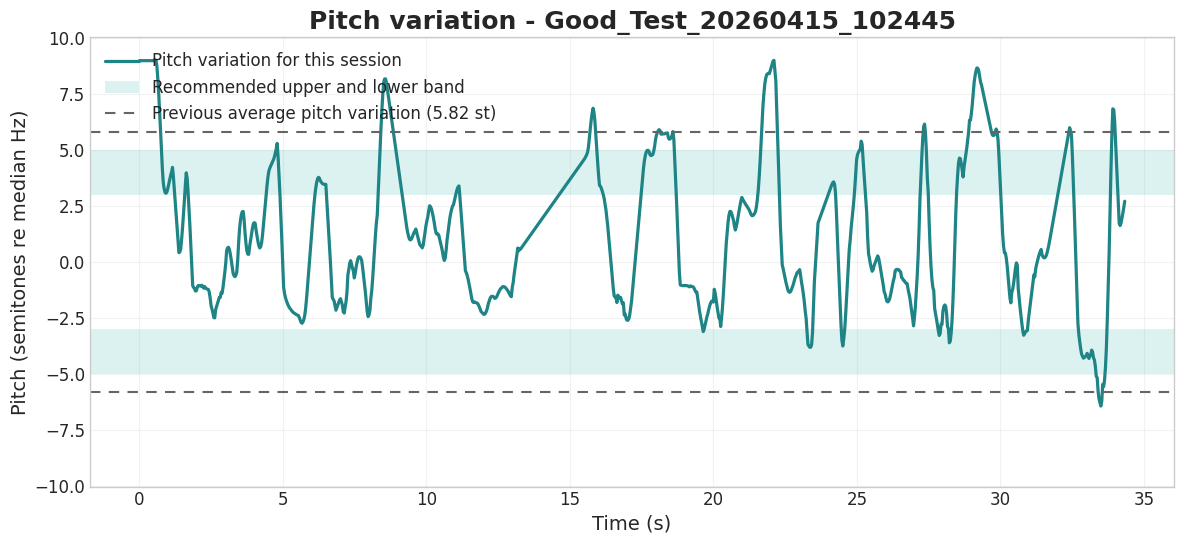

Previous weighted average variation: 5.82 semitones
Pitch reference for selected recording: 222.39 Hz
Voiced ratio for selected recording: 74.4%


In [ ]:
selected_id = recording_ids[2]  # Change as needed
rec = next(r for r in recordings if r['recording_id'] == selected_id)
track = rec['pitch_track']

times = np.array([p['time'] for p in track], dtype=float)
pitch_st = np.array([np.nan if p.get('pitch_st') is None else p.get('pitch_st') for p in track], dtype=float)
valid_st = np.isfinite(pitch_st)
if valid_st.sum() == 0:
    raise ValueError('No voiced pitch values in selected recording.')

# Build a continuous contour by interpolating across unvoiced gaps.
frame_idx = np.arange(len(pitch_st), dtype=float)
voiced_idx = frame_idx[valid_st]
continuous = np.interp(frame_idx, voiced_idx, pitch_st[valid_st])

# Smooth the contour for readability.
window = 7
if window % 2 == 0:
    window += 1
kernel = np.ones(window, dtype=float) / window
pad = window // 2
smoothed = np.convolve(np.pad(continuous, (pad, pad), mode='edge'), kernel, mode='valid')

def recording_variation(rec_item):
    t = rec_item.get('pitch_track', [])
    if not t:
        return np.nan

    st = np.array([np.nan if p.get('pitch_st') is None else p.get('pitch_st') for p in t], dtype=float)
    valid = np.isfinite(st)
    if valid.sum() >= 3:
        # Robust variation score: half of the 10th-90th percentile span.
        p10, p90 = np.nanpercentile(st[valid], [10, 90])
        return float((p90 - p10) / 2.0)

    # Fallback to detector summary if the track is too sparse for percentiles.
    summary = rec_item.get('pitch_summary', {})
    min_st = summary.get('min_st')
    max_st = summary.get('max_st')
    if min_st is not None and max_st is not None:
        return float((max_st - min_st) / 2.0)

    return np.nan

# Order is defined by notebook data order (recording_ids / recordings).
selected_pos = recording_ids.index(selected_id) if selected_id in recording_ids else None

# Weighted previous average variation: newer recordings count more.
previous_weighted_avg = None
if selected_pos is not None and selected_pos > 0:
    previous_recs = recordings[:selected_pos]
    previous_vals = [recording_variation(r) for r in previous_recs]
    previous_vals = [v for v in previous_vals if np.isfinite(v)]
    if previous_vals:
        decay = 0.65
        n = len(previous_vals)
        # Newer previous recordings get larger weights.
        weights = np.array([decay ** (n - 1 - i) for i in range(n)], dtype=float)
        previous_weighted_avg = float(np.sum(np.array(previous_vals) * weights) / np.sum(weights))

fig, ax = plt.subplots(figsize=(12, 5.6))
line_color = DEEP_TEAL
ax.plot(times, smoothed, color=line_color, linewidth=2.3, label='Pitch variation for this session')

# Recommended bands: +3 to +5 and -5 to -3 semitones.
ax.axhspan(3.0, 5.0, facecolor=PRIMARY_TEAL, alpha=0.16, edgecolor='none')
ax.axhspan(-5.0, -3.0, facecolor=PRIMARY_TEAL, alpha=0.16, edgecolor='none', label='Recommended upper and lower band')

if previous_weighted_avg is not None:
    ax.axhline(previous_weighted_avg, color=SLATE, linestyle=(0, (5, 4)), linewidth=1.5)
    ax.axhline(-previous_weighted_avg, color=SLATE, linestyle=(0, (5, 4)), linewidth=1.5, label=f'Previous average pitch variation ({previous_weighted_avg:.2f} st)')

ymax = max(10.0, np.nanmax(np.abs(smoothed)) + 1.0)
if previous_weighted_avg is not None:
    ymax = max(ymax, previous_weighted_avg + 1.0)
ax.set_ylim(-ymax, ymax)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Pitch (semitones re median Hz)')
ax.set_title(f'Pitch variation - {selected_id}')
ax.grid(True, alpha=0.25)
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

if previous_weighted_avg is not None:
    print(f'Previous weighted average variation: {previous_weighted_avg:.2f} semitones')
else:
    print('No previous recordings available for weighted average.')

print(f"Pitch reference for selected recording: {rec['pitch_summary']['reference_hz']:.2f} Hz")
print(f"Voiced ratio for selected recording: {100.0 * rec['pitch_summary']['voiced_ratio']:.1f}%")

## Optional next steps\n
- Change `selected_id` in the relevant cells to inspect another recording.\n
- Add more .wav files to `Sound_recordings/` and rerun the data-loading cell.\n
- Add export cells (`plt.savefig(...)`) for static report figures.

## 6) Filler count vs speaking pace

This scatter plot shows whether faster speaking correlates with more filler words, which could indicate nervousness or difficulty keeping up with thoughts.

In [9]:
import plotly.graph_objects as go


def _wrap_text(text, width=16):
    if len(text) <= width:
        return text
    return '<br>'.join(text[i:i + width] for i in range(0, len(text), width))


# Collect filler counts and average WPM for each recording
filler_counts = []
avg_wpm_values = []
rec_labels = []

for rec in recordings:
    total_fillers = len(rec.get('filler_events', []))
    filler_counts.append(total_fillers)

    rolling_wpm = rec.get('rolling_wpm_30s', [])
    if rolling_wpm:
        avg_wpm = float(np.mean([p['wpm'] for p in rolling_wpm]))
    else:
        avg_wpm = 0.0
    avg_wpm_values.append(avg_wpm)
    rec_labels.append(rec['recording_id'])

wrapped_labels = [_wrap_text(label, width=16) for label in rec_labels]
customdata = list(zip(wrapped_labels, avg_wpm_values, filler_counts))

fig = go.Figure(
    data=[
        go.Scatter(
            x=avg_wpm_values,
            y=filler_counts,
            mode='markers',
            marker={
                'size': 13,
                'color': PRIMARY_TEAL,
                'line': {'color': DARK_TEAL, 'width': 1.4},
                'opacity': 0.8,
            },
            customdata=customdata,
            hovertemplate=(
                '<b>Recording name:</b> <b>%{customdata[0]}</b><br>'
                + '<b>Avg WPM:</b> <b>%{customdata[1]:.1f}</b><br>'
                + '<b>Filler words:</b> <b>%{customdata[2]}</b><extra></extra>'
            ),
            showlegend=False,
        )
    ]
)

fig.update_layout(
    title='Filler Count vs Speaking Pace',
    xaxis_title='',
    yaxis_title='Total Filler Word Count',
    template='plotly_white',
    width=700,
    height=470,
    font={'family': 'DejaVu Sans', 'size': 13, 'color': '#1f2937'},
    margin={'l': 90, 'r': 30, 't': 70, 'b': 80},
    hoverlabel={
        'align': 'left',
        'namelength': -1,
        'font': {'size': 14},
        'bgcolor': 'rgba(245, 252, 251, 0.98)',
        'bordercolor': DEEP_TEAL,
    },
    annotations=[
        {
            'text': 'Average words per minute (WPM)',
            'xref': 'paper',
            'yref': 'paper',
            'x': 0.5,
            'y': -0.17,
            'showarrow': False,
            'xanchor': 'center',
            'yanchor': 'top',
            'font': {'size': 21},
        }
    ],
)
fig.update_xaxes(
    range=[35, 165],
    showgrid=True,
    gridcolor='rgba(39, 99, 109, 0.14)',
    showline=True,
    linecolor='rgba(39, 99, 109, 0.35)',
    ticks='outside',
)
fig.update_yaxes(
    showgrid=True,
    gridcolor='rgba(39, 99, 109, 0.14)',
    showline=True,
    linecolor='rgba(39, 99, 109, 0.35)',
    ticks='outside',
)
fig.show()

# Calculate correlation if there are enough points
if len(filler_counts) > 2:
    correlation = np.corrcoef(avg_wpm_values, filler_counts)[0, 1]
    print(f"Correlation between WPM and filler count: {correlation:.3f}")

Correlation between WPM and filler count: 0.470


## 7) Filler words over time (interactive trend)

This plot uses each recording timestamp (date + time) and aggregates filler usage by date, month, or year.

- X-axis: date, month, or year
- Y-axis: count of filler occurrences
- One line per filler word
- When you choose Specific month, pick a month and the plot shows all recordings in that month across the full day range
- Click legend entries to toggle lines
- Hover each point for detailed values and contributing recordings

In [10]:
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display
from datetime import datetime, timedelta
from collections import defaultdict


def _recording_timestamp(rec):
    ts = parse_timestamp(rec.get('recording_id', ''))
    if not ts:
        return None
    try:
        return datetime.strptime(ts, '%Y%m%d_%H%M%S')
    except ValueError:
        return None


def _format_recording_list(recording_ids_in_period, items_per_line=2):
    def _clean_recording_name(rec_id):
        return re.sub(r'_\d{8}_\d{6}$', '', rec_id)

    ids_sorted = sorted(_clean_recording_name(rec_id) for rec_id in recording_ids_in_period)
    if not ids_sorted:
        return 'None'

    lines = []
    for i in range(0, len(ids_sorted), items_per_line):
        lines.append(', '.join(ids_sorted[i:i + items_per_line]))
    return '<br>'.join(lines)


def _month_start(dt):
    return datetime(dt.year, dt.month, 1)


def _next_month_start(dt):
    if dt.month == 12:
        return datetime(dt.year + 1, 1, 1)
    return datetime(dt.year, dt.month + 1, 1)


def _day_start(dt):
    return datetime(dt.year, dt.month, dt.day)


trend_rows = []
for rec in recordings:
    dt = _recording_timestamp(rec)
    if dt is None:
        continue

    counts = rec.get('filler_word_counts', {})
    for word in filler_words:
        trend_rows.append(
            {
                'recording_id': rec.get('recording_id', 'unknown'),
                'timestamp': dt,
                'word': word,
                'count': int(counts.get(word, 0)),
            }
        )

if not trend_rows:
    print('No timestamped recordings found. Ensure recording IDs include YYYYMMDD_HHMMSS.')
else:
    granularity_dropdown = widgets.Dropdown(
        options=[('Specific month', 'date'), ('Monthly', 'month'), ('Yearly', 'year')],
        value='month',
        description='Group by:',
        layout=widgets.Layout(width='260px'),
    )

    month_starts = sorted({_month_start(row['timestamp']) for row in trend_rows})
    month_dropdown = widgets.Dropdown(
        options=[(dt.strftime('%B %Y'), dt) for dt in month_starts],
        value=month_starts[0],
        description='Month:',
        layout=widgets.Layout(width='260px'),
    )

    title_html = widgets.HTML()

    # Prefer the same unique color mapping as plot 1 when available.
    if 'word_colors' in globals() and isinstance(word_colors, dict):
        plot7_word_colors = {w: word_colors.get(w, '#1f77b4') for w in filler_words}
    elif '_build_unique_word_colors' in globals():
        plot7_word_colors = _build_unique_word_colors(filler_words)
    else:
        distinct_colors = [
            '#1f77b4', '#d62728', '#2ca02c', '#9467bd', '#ff7f0e',
            '#17becf', '#e377c2', '#8c564b', '#bcbd22', '#7f7f7f',
        ]
        plot7_word_colors = {w: distinct_colors[i % len(distinct_colors)] for i, w in enumerate(filler_words)}

    def _sync_controls(*args):
        month_dropdown.layout.display = 'flex' if granularity_dropdown.value == 'date' else 'none'

    def _build_plot(granularity, month):
        grouped = defaultdict(lambda: {'count': 0, 'recordings': set()})
        x_values = []
        x_label = 'Month'
        tick_fmt = '%Y-%m'
        range_start = None
        range_end = None

        if granularity == 'date':
            range_start = month
            range_end = _next_month_start(month)
            x_label = 'Date'
            tick_fmt = '%b %d'
            x_values = [range_start + timedelta(days=i) for i in range((range_end - range_start).days)]
            rows = [row for row in trend_rows if _month_start(row['timestamp']) == month]
            for row in rows:
                key = (_day_start(row['timestamp']), row['word'])
                grouped[key]['count'] += row['count']
                grouped[key]['recordings'].add(row['recording_id'])
        elif granularity == 'year':
            x_values = sorted({datetime(row['timestamp'].year, 1, 1) for row in trend_rows})
            x_label = 'Year'
            tick_fmt = '%Y'
            rows = trend_rows
            for row in rows:
                key = (datetime(row['timestamp'].year, 1, 1), row['word'])
                grouped[key]['count'] += row['count']
                grouped[key]['recordings'].add(row['recording_id'])
        else:
            x_values = sorted({_month_start(row['timestamp']) for row in trend_rows})
            x_label = 'Month'
            tick_fmt = '%Y-%m'
            rows = trend_rows
            for row in rows:
                key = (_month_start(row['timestamp']), row['word'])
                grouped[key]['count'] += row['count']
                grouped[key]['recordings'].add(row['recording_id'])

        words_to_plot = [
            word
            for word in filler_words
            if any((grouped[(x, word)]['count'] if (x, word) in grouped else 0) > 0 for x in x_values)
        ]
        if not words_to_plot:
            words_to_plot = list(filler_words)

        fig = go.Figure()
        for word in words_to_plot:
            ys = [grouped[(x, word)]['count'] if (x, word) in grouped else 0 for x in x_values]
            rec_counts = [len(grouped[(x, word)]['recordings']) if (x, word) in grouped else 0 for x in x_values]
            rec_lists = [
                _format_recording_list(grouped[(x, word)]['recordings']) if (x, word) in grouped else 'None'
                for x in x_values
            ]
            line_color = plot7_word_colors[word]

            fig.add_trace(
                go.Scatter(
                    x=x_values,
                    y=ys,
                    mode='lines+markers',
                    marker={'size': 8, 'color': line_color},
                    line={'width': 3, 'color': line_color},
                    name=word,
                    customdata=list(zip(rec_counts, rec_lists)),
                    hovertemplate=(
                        '<b>%{fullData.name}</b><br>'
                        + f'{x_label}: %{{x|{tick_fmt}}}<br>'
                        + 'Count: %{y}<br>'
                        + 'Appears in %{customdata[0]} recording(s)<br>'
                        + '<b>Recordings</b><br>%{customdata[1]}'
                        + '<extra></extra>'
                    ),
                )
            )

        if granularity == 'date':
            title_text = f'Filler Word Usage by Date - {month.strftime("%B %Y")}'
        else:
            title_text = f'Filler Word Usage Over Time ({granularity.title()})'

        fig.update_layout(
            title=title_text,
            xaxis_title=x_label,
            yaxis_title='Filler count',
            template='plotly_white',
            font={'family': 'DejaVu Sans', 'size': 16, 'color': '#1f2937'},
            title_font={'size': 30},
            hovermode='closest',
            legend_title='Filler word',
            legend={'font': {'size': 16}, 'title': {'font': {'size': 18}}},
            height=620,
            margin={'l': 90, 'r': 80, 't': 100, 'b': 90},
            hoverlabel={
                'bgcolor': 'rgba(245, 252, 251, 0.98)',
                'bordercolor': DEEP_TEAL,
                'font': {'size': 16, 'family': 'DejaVu Sans', 'color': '#102a2d'},
                'align': 'left',
                'namelength': -1,
            },
            paper_bgcolor='white',
            plot_bgcolor='white',
        )

        if granularity == 'date':
            fig.update_xaxes(
                tickformat=tick_fmt,
                showgrid=True,
                gridcolor='rgba(39, 99, 109, 0.14)',
                range=[range_start, range_end - timedelta(seconds=1)],
            )
        else:
            fig.update_xaxes(tickformat=tick_fmt, showgrid=True, gridcolor='rgba(39, 99, 109, 0.14)')
        fig.update_yaxes(showgrid=True, gridcolor='rgba(39, 99, 109, 0.14)')

        if granularity == 'date':
            title_html.value = (
                f'<b style="font-family: DejaVu Sans; font-size: 15px; color: #1f2937;">Selected month:</b> '
                f'<span style="font-family: DejaVu Sans; font-size: 15px; color: #1f2937;">{month.strftime("%B %Y")}</span>'
            )
        else:
            start_ts = min(row['timestamp'] for row in trend_rows)
            end_ts = max(row['timestamp'] for row in trend_rows)
            title_html.value = (
                f'<b style="font-family: DejaVu Sans; font-size: 15px; color: #1f2937;">Date range:</b> '
                f'<span style="font-family: DejaVu Sans; font-size: 15px; color: #1f2937;">{start_ts.strftime("%Y-%m-%d %H:%M:%S")} '
                f'to {end_ts.strftime("%Y-%m-%d %H:%M:%S")}</span>'
            )
        fig.show()

    granularity_dropdown.observe(_sync_controls, names='value')
    _sync_controls()
    out = widgets.interactive_output(_build_plot, {'granularity': granularity_dropdown, 'month': month_dropdown})
    display(widgets.VBox([title_html, granularity_dropdown, month_dropdown, out]))

## 8) Words per minute over time (interactive)

This plot tracks speaking pace (WPM) across recordings over time using your recording timestamps and WPM values from the Speed outputs.

- X-axis: recording date/time
- Y-axis: words per minute (WPM)
- Interactive window: All, Last 10, Last 5 recordings
- Hover: recording name, timestamp, WPM

In [11]:
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display
from datetime import datetime


def _recording_dt(rec):
    ts = parse_timestamp(rec.get('recording_id', ''))
    if not ts:
        return None
    try:
        return datetime.strptime(ts, '%Y%m%d_%H%M%S')
    except ValueError:
        return None


wpm_rows = []
for rec in recordings:
    dt = _recording_dt(rec)
    if dt is None:
        continue
    rid = rec.get('recording_id', 'unknown')
    clean_name = re.sub(r'_\d{8}_\d{6}$', '', rid)
    wpm_value = float(rec.get('wpm', 0.0))
    wpm_rows.append({
        'recording_id': rid,
        'clean_name': clean_name,
        'timestamp': dt,
        'wpm': wpm_value,
    })

wpm_rows = sorted(wpm_rows, key=lambda x: x['timestamp'])

if not wpm_rows:
    print('No timestamped WPM data available. Ensure recording names include YYYYMMDD_HHMMSS and Speed files are loaded.')
else:
    years = sorted({row['timestamp'].year for row in wpm_rows})
    year_dropdown = widgets.Dropdown(
        options=[(str(year), year) for year in years],
        value=years[-1],
        description='Year:',
        layout=widgets.Layout(width='220px'),
    )

    def _build_wpm_plot(selected_year):
        rows = [row for row in wpm_rows if row['timestamp'].year == selected_year]
        if not rows:
            print(f'No WPM rows found for year {selected_year}.')
            return

        xs = [r['timestamp'].date() for r in rows]
        ys = [r['wpm'] for r in rows]
        labels = [r['clean_name'] for r in rows]
        full_ids = [r['recording_id'] for r in rows]
        full_ts = [r['timestamp'].strftime('%Y-%m-%d %H:%M:%S') for r in rows]

        fig = go.Figure(
            data=[
                go.Scatter(
                    x=xs,
                    y=ys,
                    mode='lines+markers',
                    line={'width': 3, 'color': PRIMARY_TEAL},
                    marker={
                        'size': 9,
                        'color': ACCENT_CORAL,
                        'line': {'color': DARK_TEAL, 'width': 1.2},
                    },
                    customdata=list(zip(labels, full_ids, full_ts)),
                    hovertemplate=(
                        '<b>Recording:</b> %{customdata[0]}<br>'
                        + '<b>Timestamp:</b> %{customdata[2]}<br>'
                        + '<b>WPM:</b> %{y:.2f}<br>'
                        + '<b>File name:</b> %{customdata[1]}'
                        + '<extra></extra>'
                    ),
                    showlegend=False,
                )
            ]
        )

        fig.update_layout(
            title=f'Words Per Minute Over Time ({selected_year})',
            xaxis_title='Recording date',
            yaxis_title='Words per minute (WPM)',
            template='plotly_white',
            autosize=True,
            height=520,
            font={'family': 'DejaVu Sans', 'size': 13, 'color': '#1f2937'},
            margin={'l': 85, 'r': 20, 't': 75, 'b': 80},
            hoverlabel={
                'align': 'left',
                'namelength': -1,
                'font': {'size': 14},
                'bgcolor': 'rgba(245, 252, 251, 0.98)',
                'bordercolor': DEEP_TEAL,
            },
        )

        fig.update_xaxes(
            showgrid=True,
            gridcolor='rgba(39, 99, 109, 0.14)',
            tickformat='%Y-%m-%d',
            showline=True,
            linecolor='rgba(39, 99, 109, 0.35)',
            ticks='outside',
        )
        fig.update_yaxes(
            showgrid=True,
            gridcolor='rgba(39, 99, 109, 0.14)',
            showline=True,
            linecolor='rgba(39, 99, 109, 0.35)',
            ticks='outside',
            rangemode='tozero',
        )
        fig.show(config={'responsive': True})

    out = widgets.interactive_output(_build_wpm_plot, {'selected_year': year_dropdown})
    display(widgets.VBox([year_dropdown, out]))

## 9) Words per minute histogram (interactive)

This histogram shows the distribution of speaking pace (WPM) for recordings in a selected year and optional month, using fixed bin edges shared across all years for fair comparison.

- X-axis: words per minute (WPM)
- Y-axis: number of recordings in each WPM bin
- Interactive filters: year + optional month
- Fixed bins: 10 WPM width across the full dataset
- Hover: WPM bin value and count

In [12]:
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display
from datetime import datetime
import math


def _recording_dt_hist(rec):
    ts = parse_timestamp(rec.get('recording_id', ''))
    if not ts:
        return None
    try:
        return datetime.strptime(ts, '%Y%m%d_%H%M%S')
    except ValueError:
        return None


wpm_hist_rows = []
for rec in recordings:
    dt = _recording_dt_hist(rec)
    if dt is None:
        continue
    rid = rec.get('recording_id', 'unknown')
    wpm_hist_rows.append({
        'recording_id': rid,
        'timestamp': dt,
        'wpm': float(rec.get('wpm', 0.0)),
    })

wpm_hist_rows = sorted(wpm_hist_rows, key=lambda x: x['timestamp'])

if not wpm_hist_rows:
    print('No timestamped WPM data available. Ensure recording names include YYYYMMDD_HHMMSS and Speed files are loaded.')
else:
    years = sorted({row['timestamp'].year for row in wpm_hist_rows})
    months_by_year = {
        year: sorted({row['timestamp'].month for row in wpm_hist_rows if row['timestamp'].year == year})
        for year in years
    }

    year_dropdown_hist = widgets.Dropdown(
        options=[(str(year), year) for year in years],
        value=years[-1],
        description='Year:',
        layout=widgets.Layout(width='220px'),
    )
    month_dropdown_hist = widgets.Dropdown(
        description='Month:',
        layout=widgets.Layout(width='240px'),
    )

    def _month_label(month_number):
        return datetime(2000, month_number, 1).strftime('%B')

    def _set_month_options(selected_year):
        available_months = months_by_year.get(selected_year, [])
        options = [('All months', 'all')] + [(_month_label(month), month) for month in available_months]
        month_dropdown_hist.options = options
        current_values = [value for _, value in options]
        if month_dropdown_hist.value not in current_values:
            month_dropdown_hist.value = 'all'

    # Fixed bins across all years for comparable distributions.
    BIN_WIDTH_WPM = 10.0
    all_wpm_values = [row['wpm'] for row in wpm_hist_rows]
    min_wpm = min(all_wpm_values)
    max_wpm = max(all_wpm_values)
    bin_start = math.floor(min_wpm / BIN_WIDTH_WPM) * BIN_WIDTH_WPM
    bin_end = (math.ceil(max_wpm / BIN_WIDTH_WPM) + 1) * BIN_WIDTH_WPM

    def _build_wpm_histogram(selected_year, selected_month):
        rows = [row for row in wpm_hist_rows if row['timestamp'].year == selected_year]
        if selected_month != 'all':
            rows = [row for row in rows if row['timestamp'].month == selected_month]

        if not rows:
            if selected_month == 'all':
                print(f'No WPM rows found for year {selected_year}.')
            else:
                month_text = _month_label(selected_month)
                print(f'No WPM rows found for {month_text} {selected_year}.')
            return

        wpm_values = [r['wpm'] for r in rows]

        fig = go.Figure(
            data=[
                go.Histogram(
                    x=wpm_values,
                    xbins={
                        'start': bin_start,
                        'end': bin_end,
                        'size': BIN_WIDTH_WPM,
                    },
                    marker={
                        'color': PRIMARY_TEAL,
                        'line': {'color': DARK_TEAL, 'width': 1},
                    },
                    hovertemplate=(
                        '<b>WPM bin:</b> %{x}<br>'
                        + '<b>Recordings in bin:</b> %{y}'
                        + '<extra></extra>'
                    ),
                    opacity=0.88,
                    showlegend=False,
                )
            ]
        )

        avg_wpm = float(sum(wpm_values) / len(wpm_values)) if wpm_values else 0.0
        if selected_month == 'all':
            window_label = f'{selected_year}'
        else:
            window_label = f'{_month_label(selected_month)} {selected_year}'

        fig.update_layout(
            title=f'WPM Distribution by Recording ({window_label})',
            xaxis_title='Words per minute (WPM)',
            yaxis_title='Number of recordings',
            template='plotly_white',
            autosize=True,
            height=520,
            font={'family': 'DejaVu Sans', 'size': 13, 'color': '#1f2937'},
            margin={'l': 85, 'r': 20, 't': 75, 'b': 80},
            bargap=0.08,
            hoverlabel={
                'align': 'left',
                'namelength': -1,
                'font': {'size': 14},
                'bgcolor': 'rgba(245, 252, 251, 0.98)',
                'bordercolor': DEEP_TEAL,
            },
            annotations=[
                {
                    'text': f'Average WPM: {avg_wpm:.2f}',
                    'xref': 'paper',
                    'yref': 'paper',
                    'x': 0.99,
                    'y': 0.98,
                    'showarrow': False,
                    'xanchor': 'right',
                    'yanchor': 'top',
                    'font': {'size': 13, 'color': '#1f2937'},
                },
                {
                    'text': f'Fixed bin width: {BIN_WIDTH_WPM:.0f} WPM',
                    'xref': 'paper',
                    'yref': 'paper',
                    'x': 0.99,
                    'y': 0.92,
                    'showarrow': False,
                    'xanchor': 'right',
                    'yanchor': 'top',
                    'font': {'size': 12, 'color': '#374151'},
                }
            ],
        )

        fig.update_xaxes(
            showgrid=True,
            gridcolor='rgba(39, 99, 109, 0.14)',
            showline=True,
            linecolor='rgba(39, 99, 109, 0.35)',
            ticks='outside',
            range=[bin_start, bin_end],
        )
        fig.update_yaxes(
            showgrid=True,
            gridcolor='rgba(39, 99, 109, 0.14)',
            showline=True,
            linecolor='rgba(39, 99, 109, 0.35)',
            ticks='outside',
            rangemode='tozero',
        )
        fig.show(config={'responsive': True})

    def _on_year_change(change):
        _set_month_options(change['new'])

    year_dropdown_hist.observe(_on_year_change, names='value')
    _set_month_options(year_dropdown_hist.value)

    out_hist = widgets.interactive_output(
        _build_wpm_histogram,
        {'selected_year': year_dropdown_hist, 'selected_month': month_dropdown_hist},
    )
    display(widgets.VBox([widgets.HBox([year_dropdown_hist, month_dropdown_hist]), out_hist]))